In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import scipy
from scipy.sparse import csr_matrix
import yaml
import pyranges as pr

import anndata as an
import scanpy as sc

# Load the GTF

In [2]:
%%time

# Load GTF
gtf_path = "/nfs/turbo/umms-indikar/shared/projects/reference_genome/prebuilt/refdata-gex-GRCh38-2024-A/genes/genes.gtf"
print(f"Loading GTF from: {gtf_path}")
gtf = pr.read_gtf(gtf_path).as_df()
print(f"Total entries in GTF: {len(gtf)}")

# Transcript-level annotations
transcripts = gtf[gtf.Feature == "transcript"]
transcripts = transcripts[[
    "gene_id", "gene_name", "gene_type",
    "transcript_id", "transcript_name", "transcript_type",
    "Chromosome", "Start", "End"
]].dropna(subset=["gene_name", "transcript_name"]).drop_duplicates().reset_index(drop=True)
print(f"Transcripts loaded: {len(transcripts)}")

# Gene-level annotations
genes = gtf[gtf.Feature == "gene"]
genes = genes[[
    "gene_id", "gene_name", "gene_type",
    "Chromosome", "Start", "End"
]].dropna(subset=["gene_name"]).drop_duplicates().reset_index(drop=True)
print(f"Genes loaded: {len(genes)}")

Loading GTF from: /nfs/turbo/umms-indikar/shared/projects/reference_genome/prebuilt/refdata-gex-GRCh38-2024-A/genes/genes.gtf
Total entries in GTF: 3293161
Transcripts loaded: 226005
Genes loaded: 38606
CPU times: user 53.3 s, sys: 5.26 s, total: 58.6 s
Wall time: 58.7 s


# load the gene anndatas

In [3]:
%%time

outpath = "/nfs/turbo/umms-indikar/shared/projects/lab_data/genes.raw.h5ad"

hsc_subdirs = ['fast_v3', 'minion_384', 'fast_v4.2', 'hac_v4.2', 'hac_v4.3', 'hac_v3']

fpaths = {
    'cell_cycle' : "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/cc_fibroblast_full/scfib/scfib.gene_raw_feature_bc_matrix",
    'hsc' : "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/hsc_epi2me_full/",
}

# Load and tag
adatas = []
for label, path in fpaths.items():
    if not label == 'hsc':
        adata = sc.read_10x_mtx(path, var_names='gene_symbols', cache=True)
        adata.obs['dataset'] = label
        adata.obs_names = [f"{label}_{x}" for x in adata.obs_names] 
        adatas.append(adata)
        print(f"{label} {adata.shape}")
    else:
        hsc_adatas = []
        for subdir in hsc_subdirs:
            fpath = f"{path}{subdir}/{subdir}.gene_raw_feature_bc_matrix"
            adata = sc.read_10x_mtx(fpath, var_names='gene_symbols', cache=True)
            adata.obs['cell_id'] = adata.obs_names
            hsc_adatas.append(adata)
            print(f"HSC {subdir} {adata.shape}")

        adata = an.concat(hsc_adatas, join='outer', keys=hsc_subdirs)
        adata = sc.get.aggregate(
            adata, 
            by='cell_id',
            func='sum',
        )
        adata.X = adata.layers['sum']
        del adata.layers['sum']
        del adata.obs['cell_id']
        adata.obs['dataset'] = label
        adata.obs_names = [f"{label}_{x}" for x in adata.obs_names]
        adatas.append(adata)

# Concatenate into one AnnData object
adata = an.concat(adatas, join='outer', label='dataset', keys=fpaths.keys())
genes_indexed = genes.drop_duplicates(subset='gene_name').set_index('gene_name')
var_annot = adata.var.join(genes_indexed, how='left')
adata.var = var_annot

adata.write(outpath)
print(f"saved to: {outpath}")
adata

cell_cycle (8963, 23635)
HSC fast_v3 (9525, 8839)
HSC minion_384 (8583, 18677)
HSC fast_v4.2 (8646, 9358)
HSC hac_v4.2 (8657, 23924)
HSC hac_v4.3 (8587, 18742)
HSC hac_v3 (8576, 22330)


/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


saved to: /nfs/turbo/umms-indikar/shared/projects/lab_data/genes.raw.h5ad
CPU times: user 8.73 s, sys: 4.17 s, total: 12.9 s
Wall time: 16.2 s


AnnData object with n_obs × n_vars = 20366 × 26852
    obs: 'dataset'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End'

# Load the transcripts

In [4]:
%%time

hsc_subdirs = ['fast_v3', 'minion_384', 'fast_v4.2', 'hac_v4.2', 'hac_v4.3', 'hac_v3']

fpaths = {
    'cell_cycle' : "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/cc_fibroblast_full/scfib/scfib.transcript_raw_feature_bc_matrix",
    'hsc' : "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/hsc_epi2me_full/",
}

# Load and tag
adatas = []
for label, path in fpaths.items():
    if not label == 'hsc':
        adata = sc.read_10x_mtx(path, var_names='gene_symbols', cache=True)
        adata.obs['dataset'] = label
        adata.obs_names = [f"{label}_{x}" for x in adata.obs_names] 
        adatas.append(adata)
        print(f"{label} {adata.shape}")
    else:
        hsc_adatas = []
        for subdir in hsc_subdirs:
            fpath = f"{path}{subdir}/{subdir}.transcript_raw_feature_bc_matrix"
            adata = sc.read_10x_mtx(fpath, var_names='gene_symbols', cache=True)
            adata.obs['cell_id'] = adata.obs_names
            hsc_adatas.append(adata)
            print(f"HSC {subdir} {adata.shape}")

        adata = an.concat(hsc_adatas, join='outer', keys=hsc_subdirs)
        adata = sc.get.aggregate(
            adata, 
            by='cell_id',
            func='sum',
        )
        adata.X = adata.layers['sum']
        del adata.layers['sum']
        del adata.obs['cell_id']
        adata.obs['dataset'] = label
        adata.obs_names = [f"{label}_{x}" for x in adata.obs_names]
        adatas.append(adata)

# Concatenate into one AnnData object
adata = an.concat(adatas, join='outer', label='dataset', keys=fpaths.keys())

transcripts_indexed = transcripts.drop_duplicates(subset='transcript_name').set_index('transcript_id')
var_annot = adata.var.join(transcripts_indexed, how='left')
adata.var = var_annot
adata.var['transcript_id'] = adata.var.index.copy()
adata.var_names = adata.var['transcript_name'].copy()

adata

cell_cycle (8963, 63464)
HSC fast_v3 (9279, 11124)
HSC minion_384 (8579, 39453)
HSC fast_v4.2 (8426, 12175)
HSC hac_v4.2 (8657, 60494)
HSC hac_v4.3 (8579, 39922)
HSC hac_v3 (8576, 53841)


/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


CPU times: user 10.8 s, sys: 4.45 s, total: 15.2 s
Wall time: 15.4 s


AnnData object with n_obs × n_vars = 19924 × 94528
    obs: 'dataset'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_name', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id'

In [5]:
adata.var.head()

,gene_id,gene_name,gene_type,transcript_name,transcript_type,Chromosome,Start,End,transcript_id
transcript_name,,,,,,,,,
ARF5-201,ENSG00000004059,ARF5,protein_coding,ARF5-201,protein_coding,chr7,127588410,127591700,ENST00000000233
M6PR-201,ENSG00000003056,M6PR,protein_coding,M6PR-201,protein_coding,chr12,8940360,8949645,ENST00000000412
ESRRA-201,ENSG00000173153,ESRRA,protein_coding,ESRRA-201,protein_coding,chr11,64305523,64316743,ENST00000000442
FKBP4-201,ENSG00000004478,FKBP4,protein_coding,FKBP4-201,protein_coding,chr12,2794969,2805423,ENST00000001008
NDUFAF7-201,ENSG00000003509,NDUFAF7,protein_coding,NDUFAF7-201,protein_coding,chr2,37231657,37249160,ENST00000002125


# Load gene expression data

In [6]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/pseudotime.h5ad"
bdata = sc.read_h5ad(fpath)
bdata

CPU times: user 403 ms, sys: 1.77 s, total: 2.18 s
Wall time: 5.63 s


AnnData object with n_obs × n_vars = 15867 × 21412
    obs: 'batch', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'n_reads', 'raw_clusters', 'bbknn_clusters', 'harmony_clusters', 'cluster_str', 'barcoded_phase', 'S_score', 'G2M_score', 'dpt_pseudotime', 'dpt_groups', 'dpt_order', 'dpt_order_indices', 'G1_pseudotime', 'G1_order', 'G2M_pseudotime', 'G2M_order', 'mean_pseudotime', 'mean_order', 'nnz'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersio

# Filter cells and ensure ordering

In [7]:
%%time

print(f"Initial number of cells in adata: {adata.n_obs}")
print(f"Number of cells in bdata: {bdata.n_obs}")

# Remove data-specific IDs
adata.obs_names = [x.split("_")[-1] for x in adata.obs_names]
print(f"Number of cells in adata after stripping IDs: {adata.n_obs}")

# Subset adata to those present in bdata
cells_to_keep = adata.obs_names.isin(bdata.obs_names)
print(f"Number of cells in adata after filtering by bdata: {cells_to_keep.sum()}")

adata = adata[cells_to_keep, :].copy()
print(f"Final number of cells in adata: {adata.n_obs}")

# Sort adata and bdata to the same order (shared cells only)
shared_cells = bdata.obs_names.intersection(adata.obs_names)
print(f"Number of shared cells: {len(shared_cells)}")

# Sort both AnnData objects
adata = adata[shared_cells, :].copy()
bdata_sorted = bdata[shared_cells, :].copy()

# Assert same order
assert all(adata.obs_names == bdata_sorted.obs_names), "Cell ordering does not match!"
print("Cell ordering is identical between adata and bdata (shared cells).")

Initial number of cells in adata: 19924
Number of cells in bdata: 15867
Number of cells in adata after stripping IDs: 19924
Number of cells in adata after filtering by bdata: 15867
Final number of cells in adata: 15867
Number of shared cells: 15867
Cell ordering is identical between adata and bdata (shared cells).
CPU times: user 870 ms, sys: 2.74 s, total: 3.61 s
Wall time: 3.62 s


In [8]:
adata.obs.head()

,dataset
AAACCCAAGGTTACCT-1,hsc
AAACCCAAGTTGAAGT-1,hsc
AAACCCAAGTTGTCGT-1,hsc
AAACCCACAGAAGCGT-1,hsc
AAACCCACAGGAGGTT-1,hsc


# Merge Obs

In [9]:
%%time

obs_columns = [
    'batch',
    'phase',
    'n_counts',
    'n_genes',
    'n_reads',
    'cluster_str',
    'mean_pseudotime',
    'mean_order',
]

print(f"Before merge: adata.obs columns = {list(adata.obs.columns)}")

# Subset bdata.obs to the needed columns
df_merge = bdata.obs[obs_columns].copy()
df_merge.index.name = "cell"

# Merge by index (obs_names)
adata.obs = adata.obs.merge(df_merge, left_index=True, right_index=True, suffixes=('', '_bdata'))

print(f"After merge: adata.obs columns = {list(adata.obs.columns)}")
print(f"Example merged obs (first 5 rows):\n{adata.obs.head()}")

adata.obsm['X_draw_graph_fa'] = bdata.obsm['X_draw_graph_fa'].copy()
adata.uns["draw_graph"] = bdata.uns["draw_graph"].copy()

Before merge: adata.obs columns = ['dataset']
After merge: adata.obs columns = ['dataset', 'batch', 'phase', 'n_counts', 'n_genes', 'n_reads', 'cluster_str', 'mean_pseudotime', 'mean_order']
Example merged obs (first 5 rows):
                   dataset batch phase  n_counts  n_genes  n_reads  \
AAACCCAAGGTTACCT-1     hsc   hsc    G1   11202.0     3679  11202.0   
AAACCCAAGTTGAAGT-1     hsc   hsc    G1   10579.0     3987  10579.0   
AAACCCAAGTTGTCGT-1     hsc   hsc     S    6735.0     2585   6735.0   
AAACCCACAGAAGCGT-1     hsc   hsc    G1    5416.0     2358   5416.0   
AAACCCACAGGAGGTT-1     hsc   hsc    G1   21937.0     4997  21937.0   

                   cluster_str  mean_pseudotime  mean_order  
AAACCCAAGGTTACCT-1          C3         0.808782         0.0  
AAACCCAAGTTGAAGT-1          C3         0.922000      7688.0  
AAACCCAAGTTGTCGT-1          C4         0.264203      9543.0  
AAACCCACAGAAGCGT-1          C5         0.295864     15150.0  
AAACCCACAGGAGGTT-1          C2         0.78

# merge in gene expression counts

In [10]:
adata.uns['log_norm_GEX'] = bdata.to_df(layer='log_norm').copy()
adata.uns['raw_counts_GEX'] = bdata.to_df(layer='raw_counts').copy()

In [11]:
adata.var.head()

,gene_id,gene_name,gene_type,transcript_name,transcript_type,Chromosome,Start,End,transcript_id
transcript_name,,,,,,,,,
ARF5-201,ENSG00000004059,ARF5,protein_coding,ARF5-201,protein_coding,chr7,127588410,127591700,ENST00000000233
M6PR-201,ENSG00000003056,M6PR,protein_coding,M6PR-201,protein_coding,chr12,8940360,8949645,ENST00000000412
ESRRA-201,ENSG00000173153,ESRRA,protein_coding,ESRRA-201,protein_coding,chr11,64305523,64316743,ENST00000000442
FKBP4-201,ENSG00000004478,FKBP4,protein_coding,FKBP4-201,protein_coding,chr12,2794969,2805423,ENST00000001008
NDUFAF7-201,ENSG00000003509,NDUFAF7,protein_coding,NDUFAF7-201,protein_coding,chr2,37231657,37249160,ENST00000002125


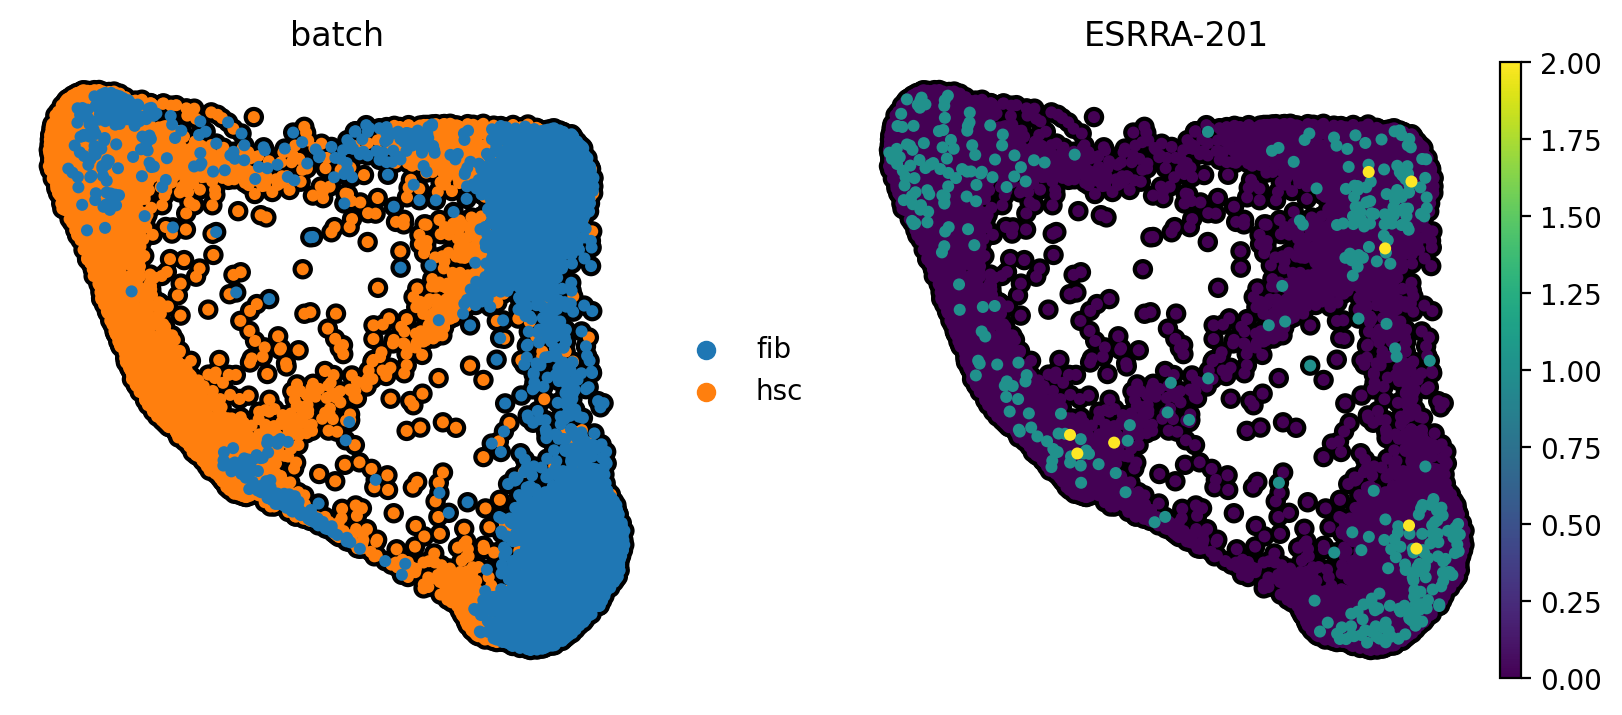

In [12]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.draw_graph(
    adata,
    ncols=4,
    sort_order=True,
    color=['batch', 'ESRRA-201'],
    size=75,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    frameon=False,
)

In [13]:
# break

In [14]:
%%time
outpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/isoforms.h5ad"
adata.write(outpath)
print(f"saved to: {outpath}")

saved to: /nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/isoforms.h5ad
CPU times: user 27.4 s, sys: 3.62 s, total: 31.1 s
Wall time: 42.2 s
